# **3.4 Softmax回归**

### 引入

从算**值**（预测房价）的线性回归，变成算**各个分类概率**的**Softmax回归**

围绕**概率**，一个张量**y**的各个数应该是(0,1)的数，且和为一。所以需要继续转化

**交叉熵**


### 部分损失函数：
**线性回归、绝对值回归，Huber's loss**

## 3.4.1 图像分类数据集（**读取数据**）
使用fashion-MNIST数据集

In [1]:
%matplotlib inline 
#用来让notebook能显示数据图像的，我去，还不能放注释，为毛？有时间我去看看。 ans:这是专门写给notebook的
import torch
import torchvision #基于pytorch的计算机视觉库，提供了常用数据集，架构，图像转换
from torch.utils import data #创建数据加载器(DataLoader)，以批量处理数据
from torchvision import transforms #transforms是图像变化模块，可以进行预处理（把图像转化成张量？） ans:对，已按像素灰度进行归一化处理
#不对啊，不是已经导入了父类了吗，为啥子类还要再导一遍？ ans:在__init__.py中没有导入所有子模块
from d2l import torch as d2l

d2l.use_svg_display() #如其字义，用svg格式显示图

将Fashion-MNIST数据集下载并读取到内存中。

In [2]:
trans = transforms.ToTensor() #将PIL图像变为32位浮点数格式，并除以255进行了归一化（像素值原取值在0-255）
mnist_train = torchvision.datasets.FashionMNIST(
    root = "../data", train=True, transform=trans, download=True 
) 
mnist_test = torchvision.datasets.FashionMNIST(
    root = "../data", train=False, transform=trans, download=True
)
# train=True表示加载数据, transforms=trans表示数据预处理，download即若本地没有数据则下载数据

100.0%


Extracting ../data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ../data\FashionMNIST\raw



100.0%


Extracting ../data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ../data\FashionMNIST\raw



100.0%


Extracting ../data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ../data\FashionMNIST\raw



100.0%

Extracting ../data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ../data\FashionMNIST\raw



Fashion_MNIST提供了十个类别的图像，有训练集60000个，测试集10000个
每个输入图像的高度和宽度均为28像素。 数据集由灰度图像组成，其通道数为1。 为了简洁起见，本书将高度
像素h宽度w像素图像的形状记为h X w或(h,w)

要训练的10个类别，分别为t-shirt（T恤）、trouser（裤子）、pullover（套衫）、dress（连衣裙）、coat（外套）、sandal（凉鞋）、shirt（衬衫）、sneaker（运动鞋）、bag（包）和ankle boot（短靴）。

下面的函数将数字标签与文本名称对应

In [3]:
def get_fashion_mnist_labels(labels):
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

In [4]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):  #@save
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # 图片张量
            ax.imshow(img.numpy())
        else:
            # PIL图片
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

在此处发现了一个问题，torchvision==0.20.1获取到数据类型要求是np.ndarray，但是NumPy==1.25.2的数据格式是numpy.ndarray，就难绷，运行不了会报错`TypeError:expected np.ndarray(got numpy.ndarray)`,需要才conda环境中把numpy降级为1.25.0

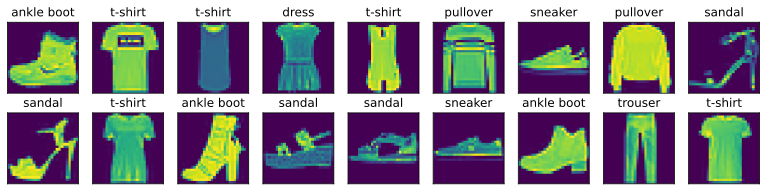

In [5]:
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y));

先记录一下，迭代器的逻辑：迭代一次就返回一个批次的数据和样本

In [6]:
batch_size = 256

def get_dataloader_workers():  #@save
    """使用4个进程来读取数据"""
    return 6

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True,
                             num_workers=get_dataloader_workers())

timer = d2l.Timer()
for X, y in train_iter:
    continue
f'{timer.stop():.2f} sec'

'10.04 sec'

我日，怎么这么慢

## **3.4.2 Softmax回归从零实现**

In [7]:
import torch
from IPython import display
from d2l import torch as d2l

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [8]:
num_inputs = 784
num_outputs = 10

W = torch.normal(0, 0.01, size=(num_inputs,num_outputs),requires_grad=True)
b = torch.zeros(num_outputs,requires_grad=True)

torch.set_printoptions(sci_mode=False)   #日内瓦为什么我的版本设置默认是科学计数法？好他娘丑啊
W, b

(tensor([[     0.0135,     -0.0007,     -0.0079,  ...,     -0.0091,
              -0.0082,      0.0023],
         [     0.0015,      0.0074,      0.0204,  ...,      0.0075,
               0.0058,      0.0104],
         [     0.0043,     -0.0084,      0.0187,  ...,      0.0039,
              -0.0038,      0.0056],
         ...,
         [     0.0073,      0.0091,     -0.0055,  ...,     -0.0044,
              -0.0110,     -0.0065],
         [     0.0001,      0.0009,      0.0051,  ...,     -0.0156,
               0.0063,      0.0012],
         [     0.0132,     -0.0103,      0.0044,  ...,     -0.0161,
              -0.0075,     -0.0002]], requires_grad=True),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True))

接下来进行归一化，进行‘softmax’

In [9]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition #广播机制，简化代码了属于是

In [10]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1,W.shape[0])), W) + b )
    #(-1,W.shape[0])得到channels的数量（所有像素按784个分批，即分成一张一张的图片）
    #然后与权重矩阵相乘（对784个东西进行加权，1-10各有一个加权数组）,得到预测数据，即y_hat

In [11]:
y = torch.tensor([0, 2, 2])
y_hat = torch.tensor([[0.3, 0.5, 0.2], [0.1, 0.1, 0.8], [0.3, 0.3, 0.4]])

def cross_entropy(y_hat,y):
    return -torch.log(y_hat[range(len(y_hat)), y])

#首先要理解交叉熵，此处意思是返回预测值在真实标号位置的概率，看看好不好。

In [12]:
def accuracy(y_hat, y):  #将accuracy翻译为“准确数”以便理解
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1 :
        y_hat = y_hat.argmax(axis=1)
        
    cmp = y_hat.type(y.dtype) == y #bool值张量
    return float(cmp.type(y.dtype).sum()) #即预测对了多少个（True的个数）

f'accuracy:{accuracy(y_hat, y) / len(y):.3f}'

'accuracy:0.667'

In [13]:
def evaluate_accuracy(net, data_iter): #@save

    if isinstance(net, torch.nn.Module):
        net.eval() #设为评估模式，咱也不知道是什么意思

    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel()) #number of elements，shit英语不好还不好理解
            #该行代码表示：metric[0] += accuracy(), metric[1] += y.numel()
        return metric[0] / metric[1]

咱来看看Accumulator这个函数，我是傻狗，我看了好久才看明白为什么能在分开在两个位置实现加法

In [14]:
class Accumulator:  #@save

    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]
        #就比如说，接收到的args是两个参数，那么这两个参数就会和self.data配对，因为a是self.data里面的，所以就相当于args里和a对应的参数，加到了a对应的位置上

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

咱看看没训练前的效果：

In [15]:
evaluate_accuracy(net, test_iter)

0.1203

### 训练
跟线性回归那里差不多，看准确率，对损失函数（现在是交叉熵）进行求导，梯度下降，优化到一定程度

在下方代码中`updater()`为自定义的优化器，没太看大懂。反正是更新参数就对了，实现梯度的下降。

In [16]:
def train_epoch_ch3(net, train_iter, loss, updater): #@save

    if isinstance(net, torch.nn.Module):
        net.train()

    metric =Accumulator(3)
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.mean().backward()
            updater.step() #根据计算出的梯度更新模型的参数

        else:
            l.sum().backward()
            updater(X.shape[0]) #按照X的0轴长度（即样本数）进行参数更新
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())

    return metric[0] / metric[2], metric[1] / metric[2]
    #返回了损失和准确性,注意return不要放在循环里面，不然准确率堪忧

下面是一个画画函数。

我练练手，复习一下基础语法里面**类**的内容：*（学完yxc基础课基础语法就来搞这个，有点高估自己了）*

In [17]:
class Animator:

    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                ylim=None, xscale='linear', yscale='linear', 
                fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                figsize=(3.5, 2.5)):

        if legend is None:
            legend =[] #把可能为空的元素或者单元素的东西转换为列表以便访问
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        #窗口， 坐标轴
        if nrows * ncols == 1:
            self.axes = [self.axes, ] #单图时转换为列表，以便于在单图时也能访问

        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        #便于之后简化代码，定义各参数并建立图表只需要写一遍即可
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n         
        #把x变成和y一样长的列表，点对应。x为一个数时可以理解为在第x天时，每个城市日期相同，但是对应的天气对应的y不同
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)   
        self.axes[0].cla()   #清除旧图形，这个类的逻辑是加一个点就画一遍图，相当于一帧一帧的搞出来动画
        for x_data, y_data, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x_data, y_data, fmt)  # 逐条绘制曲线
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

**xlabel/ylabel**：坐标轴标签（字符串），如 "epoch"、"loss"。
**legend**：图例列表（字符串列表），标识每条曲线（如 ["train loss", "test loss"]）。默认为空列表 []。
**xlim/ylim**：坐标轴范围（元组），如 (0, 100) 表示 x 轴范围 0~100。
**xscale/yscale**：坐标轴缩放方式（字符串），'linear'（线性，默认）或 'log'（对数）。
**fmts**：**曲线格式列表**（字符串元组），定义每条曲线的样式：
('-')：实线（蓝色）
('m--')：品红色虚线
('g-.')：绿色点划线
('r:')：红色点线
**nrows/ncols**：子图的行数和列数（默认 1x1 单图）。
**figsize**：图形尺寸（宽, 高），单位英寸（默认 3.5x2.5）。

——来自Qwen模型解读

训练函数实现

In [ ]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):  #@save
    animator = Animator(xlabel='epoch', xlim=[1,num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])

    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics #这里的意思应该是，[a, b] + [c, d] = [[a,b], [c,d]]
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc
    #assert大概意思是要满足要求才画吧？

In [19]:
lr = 0.05

def updater(batch_size):
    
    return d2l.sgd([W, b], lr, batch_size)

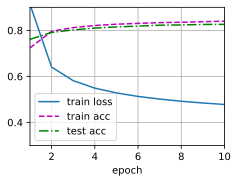

In [20]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

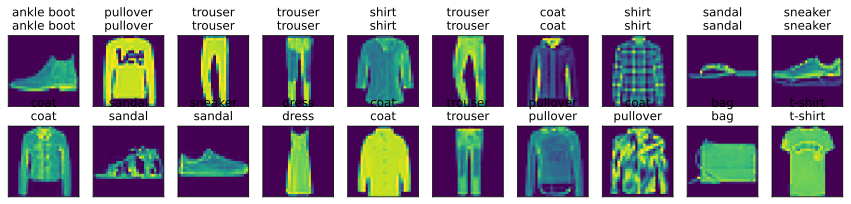

In [21]:
def predict_ch3(net, test_iter, n=20):  #@save
    """预测标签（定义见第3章）"""
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(
        X[0:n].reshape((n, 28, 28)), 2, int(n/2), titles=titles[0:n])

predict_ch3(net, test_iter)

## 3.4.3 Softmax简洁实现
没啥区别

In [22]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

初始化参数，并完成训练

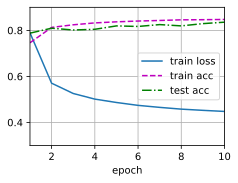

In [ ]:
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

loss = nn.CrossEntropyLoss(reduction='none')

trainer = torch.optim.SGD(net.parameters(), lr=0.1)

num_epochs = 10
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)